# 02. Univariate GARCH Models

The first notebook showed that volatility clustering is present in the daily market series, especially around crisis periods. This second notebook takes the next natural step: we model conditional volatility directly. The economic question is whether volatility became more persistent, more asymmetric or more heavy-tailed after COVID-19.

We focus on four core assets that capture equity, credit, commodity and safe-haven risk:
- S&P 500,
- US HY Bonds,
- Oil futures,
- Gold.

## 1. Setup

We reuse the exact same cleaned daily return construction as in notebook 01. This is important because any difference between the pre- and post-COVID estimates should come from the data-generating process itself, not from a change in preprocessing choices.

In [1]:
from _notebook_setup import bootstrap_notebook

bootstrap_notebook()

import pandas as pd
import matplotlib.pyplot as plt

from project2_garch_utils import (
    GARCH_ASSETS,
    GARCH_LABELS,
    MODEL_SPECS,
    load_garch_samples,
    estimate_all_garch_models,
    build_comparison_table,
    plot_conditional_volatility,
    save_garch_outputs,
)
from project2_data_utils import ensure_output_dirs, save_figure

ensure_output_dirs()

## 2. Load the analysis sample

We rebuild the aligned daily return sample from the raw Excel workbook and keep the same pre/post split used in notebook 01. This ensures that the volatility models are estimated on exactly the same empirical objects as the stylized facts.

In [2]:
aligned_returns, pre_covid, post_covid = load_garch_samples()

print(f"Full aligned sample: {aligned_returns.shape}")
print(f"Pre-COVID sample:    {pre_covid.shape}")
print(f"Post-COVID sample:   {post_covid.shape}")

Full aligned sample: (5486, 15)
Pre-COVID sample:    (4181, 15)
Post-COVID sample:   (1305, 15)


## 3. Model design

We estimate three standard models from the course for each asset and each sub-sample:
- **GARCH(1,1)** as the baseline volatility model;
- **GJR-GARCH** to test for leverage or asymmetry;
- **GARCH-t** to allow for heavy-tailed innovations.

This combination is useful because each model answers a different economic question. The baseline GARCH measures volatility persistence. The GJR-GARCH checks whether bad news changes volatility differently from good news. The Student-t specification checks whether the Gaussian assumption is too restrictive in the tails.

In [3]:
model_design = pd.DataFrame({
    "model": list(MODEL_SPECS.keys()),
    "economic_role": [
        "baseline volatility persistence",
        "asymmetric volatility / leverage effect",
        "fat tails in the innovation distribution",
    ],
})
model_design

,model,economic_role
0,"GARCH(1,1)",baseline volatility persistence
1,GJR-GARCH,asymmetric volatility / leverage effect
2,GARCH-t,fat tails in the innovation distribution


## 4. Estimate all univariate volatility models

We now estimate the full grid of models: 4 assets ? 2 sub-samples ? 3 specifications. The summary table extracts the parameters that matter most economically:
- `alpha_1` for short-run shock sensitivity,
- `beta_1` for volatility persistence,
- `gamma_1` for leverage in the GJR model,
- `nu` for tail thickness in the Student-t model.

We also save diagnostics because an estimated GARCH model is only useful if it removes most of the serial dependence left in volatility.

In [4]:
garch_summary = estimate_all_garch_models(pre_covid, post_covid)
save_garch_outputs(garch_summary)

garch_summary.head(12)

,asset,sample,model,n_obs,mu,omega,alpha_1,beta_1,gamma_1,nu,...,bic,lb_resid_stat_lag10,lb_resid_pvalue_lag10,lb_sq_resid_stat_lag10,lb_sq_resid_pvalue_lag10,engle_ng_joint_f,engle_ng_joint_pvalue,sign_bias_pvalue,negative_size_bias_pvalue,positive_size_bias_pvalue
0,sp500,Pre-COVID,"GARCH(1,1)",4181,0.0539,0.0250,0.1308,0.8506,NaN,NaN,...,11334.2163,10.9727,0.3597,5.5131,0.8544,6.4658,0.0002,0.1269,0.7260,0.0538
1,sp500,Pre-COVID,GJR-GARCH,4181,0.0185,0.0282,0.0082,0.8616,0.2081,NaN,...,11199.1842,8.8178,0.5495,4.6635,0.9125,3.7204,0.0110,0.0363,0.0064,0.6751
2,sp500,Pre-COVID,GARCH-t,4181,0.0687,0.0152,0.1287,0.8674,NaN,6.0015,...,11140.4872,11.1874,0.3431,4.5074,0.9216,5.4850,0.0009,0.1011,0.8454,0.1586
3,us_hy_bonds,Pre-COVID,"GARCH(1,1)",4181,0.0485,0.0025,0.3723,0.6277,NaN,NaN,...,-2095.9647,961.4060,0.0000,2.8969,0.9837,6.1345,0.0004,0.0005,0.1887,0.9061
4,us_hy_bonds,Pre-COVID,GJR-GARCH,4181,0.0441,0.0022,0.2283,0.6533,0.2368,NaN,...,-2175.3630,1047.5087,0.0000,5.1056,0.8840,2.8104,0.0380,0.0063,0.6531,0.0406
5,us_hy_bonds,Pre-COVID,GARCH-t,4181,0.0468,0.0020,0.3457,0.6543,NaN,5.4051,...,-2548.1751,973.7717,0.0000,3.3535,0.9718,5.5459,0.0009,0.0015,0.1064,0.8782
6,oil,Pre-COVID,"GARCH(1,1)",4181,0.0735,0.0616,0.0797,0.9105,NaN,NaN,...,17980.9253,7.4762,0.6798,6.6116,0.7615,5.3977,0.0010,0.0619,0.1906,0.4217
7,oil,Pre-COVID,GJR-GARCH,4181,0.0497,0.0507,0.0525,0.9161,0.0487,NaN,...,17971.0124,7.4976,0.6778,13.0008,0.2236,4.3754,0.0044,0.0376,0.3680,0.1955
8,oil,Pre-COVID,GARCH-t,4181,0.0836,0.0522,0.0690,0.9219,NaN,8.9756,...,17875.0659,7.7921,0.6491,9.7552,0.4622,6.0845,0.0004,0.0444,0.1342,0.2613
9,gold,Pre-COVID,"GARCH(1,1)",4181,0.0210,0.0115,0.0459,0.9438,NaN,NaN,...,11651.8711,7.0208,0.7235,30.0401,0.0008,0.4057,0.7489,0.4912,0.4456,0.4237


## 5. Compact comparison table

The raw estimation output is long, so we condense it into a more readable table focused on persistence, asymmetry and residual diagnostics. This is the table we would most naturally interpret in the report.

In [5]:
comparison_table = build_comparison_table(garch_summary)
comparison_table

,asset,sample,model,alpha_1,beta_1,gamma_1,nu,persistence,lb_resid_pvalue_lag10,lb_sq_resid_pvalue_lag10,engle_ng_joint_pvalue,asset_label
0,sp500,Pre-COVID,"GARCH(1,1)",0.1308,0.8506,NaN,NaN,0.9814,0.3597,0.8544,0.0002,S&P 500
1,sp500,Pre-COVID,GJR-GARCH,0.0082,0.8616,0.2081,NaN,0.9738,0.5495,0.9125,0.0110,S&P 500
2,sp500,Pre-COVID,GARCH-t,0.1287,0.8674,NaN,6.0015,0.9961,0.3431,0.9216,0.0009,S&P 500
3,us_hy_bonds,Pre-COVID,"GARCH(1,1)",0.3723,0.6277,NaN,NaN,1.0000,0.0000,0.9837,0.0004,US HY Bonds
4,us_hy_bonds,Pre-COVID,GJR-GARCH,0.2283,0.6533,0.2368,NaN,1.0000,0.0000,0.8840,0.0380,US HY Bonds
5,us_hy_bonds,Pre-COVID,GARCH-t,0.3457,0.6543,NaN,5.4051,1.0000,0.0000,0.9718,0.0009,US HY Bonds
6,oil,Pre-COVID,"GARCH(1,1)",0.0797,0.9105,NaN,NaN,0.9902,0.6798,0.7615,0.0010,Oil futures
7,oil,Pre-COVID,GJR-GARCH,0.0525,0.9161,0.0487,NaN,0.9929,0.6778,0.2236,0.0044,Oil futures
8,oil,Pre-COVID,GARCH-t,0.0690,0.9219,NaN,8.9756,0.9909,0.6491,0.4622,0.0004,Oil futures
9,gold,Pre-COVID,"GARCH(1,1)",0.0459,0.9438,NaN,NaN,0.9897,0.7235,0.0008,0.7489,Gold


## 6. Read the persistence and leverage patterns by asset

At this point, the most useful comparison is not model-by-model but asset-by-asset. We therefore pivot the main parameters into a format that makes the pre/post change easy to read.

In [6]:
persistence_table = comparison_table.pivot_table(
    index=["asset_label", "model"],
    columns="sample",
    values="persistence",
)
persistence_table

sample                  Post-COVID  Pre-COVID
asset_label model                            
Gold        GARCH(1,1)      0.9313     0.9897
            GARCH-t         0.9417     0.9926
            GJR-GARCH       0.9492     0.9906
Oil futures GARCH(1,1)      1.0000     0.9902
            GARCH-t         0.8968     0.9909
            GJR-GARCH       1.0000     0.9929
S&P 500     GARCH(1,1)      0.9638     0.9814
            GARCH-t         0.9766     0.9961
            GJR-GARCH       0.9580     0.9738
US HY Bonds GARCH(1,1)      1.0000     1.0000
            GARCH-t         1.0000     1.0000
            GJR-GARCH       1.0000     1.0000

In [7]:
leverage_table = comparison_table.loc[comparison_table["model"] == "GJR-GARCH", [
    "asset_label", "sample", "gamma_1", "engle_ng_joint_pvalue"
]]
leverage_table

,asset_label,sample,gamma_1,engle_ng_joint_pvalue
1,S&P 500,Pre-COVID,0.2081,0.0110
4,US HY Bonds,Pre-COVID,0.2368,0.0380
7,Oil futures,Pre-COVID,0.0487,0.0044
10,Gold,Pre-COVID,-0.0108,0.6502
13,S&P 500,Post-COVID,0.1891,0.0064
16,US HY Bonds,Post-COVID,0.1602,0.1260
19,Oil futures,Post-COVID,1.6410,0.0872
22,Gold,Post-COVID,-0.1191,0.4941


## 7. Residual diagnostics

Two diagnostics are especially important after fitting GARCH models:
- **Ljung-Box on standardized residuals**, to check whether mean dynamics remain in the filtered series;
- **Ljung-Box on squared standardized residuals**, to check whether conditional heteroskedasticity remains;
- **Engle-Ng**, to see whether asymmetry is still left unexplained.

If the p-values are comfortably above standard thresholds, the variance model is doing a reasonable job. If not, the volatility process may still be misspecified.

In [8]:
diagnostics_table = comparison_table[[
    "asset_label",
    "sample",
    "model",
    "lb_resid_pvalue_lag10",
    "lb_sq_resid_pvalue_lag10",
    "engle_ng_joint_pvalue",
]].copy()
diagnostics_table

,asset_label,sample,model,lb_resid_pvalue_lag10,lb_sq_resid_pvalue_lag10,engle_ng_joint_pvalue
0,S&P 500,Pre-COVID,"GARCH(1,1)",0.3597,0.8544,0.0002
1,S&P 500,Pre-COVID,GJR-GARCH,0.5495,0.9125,0.0110
2,S&P 500,Pre-COVID,GARCH-t,0.3431,0.9216,0.0009
3,US HY Bonds,Pre-COVID,"GARCH(1,1)",0.0000,0.9837,0.0004
4,US HY Bonds,Pre-COVID,GJR-GARCH,0.0000,0.8840,0.0380
5,US HY Bonds,Pre-COVID,GARCH-t,0.0000,0.9718,0.0009
6,Oil futures,Pre-COVID,"GARCH(1,1)",0.6798,0.7615,0.0010
7,Oil futures,Pre-COVID,GJR-GARCH,0.6778,0.2236,0.0044
8,Oil futures,Pre-COVID,GARCH-t,0.6491,0.4622,0.0004
9,Gold,Pre-COVID,"GARCH(1,1)",0.7235,0.0008,0.7489


## 8. Conditional volatility plots

Tables are useful for parameter interpretation, but volatility models are easier to understand visually when we look at the estimated conditional standard deviation. We therefore plot the baseline GARCH(1,1) volatility for each core asset before and after COVID.

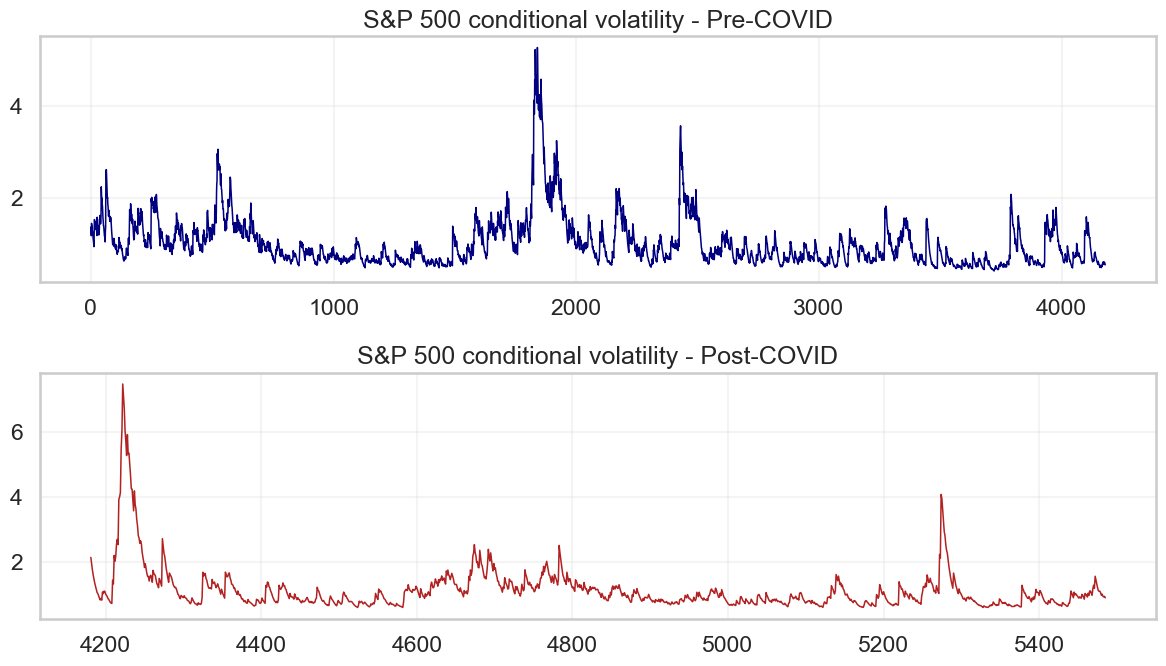

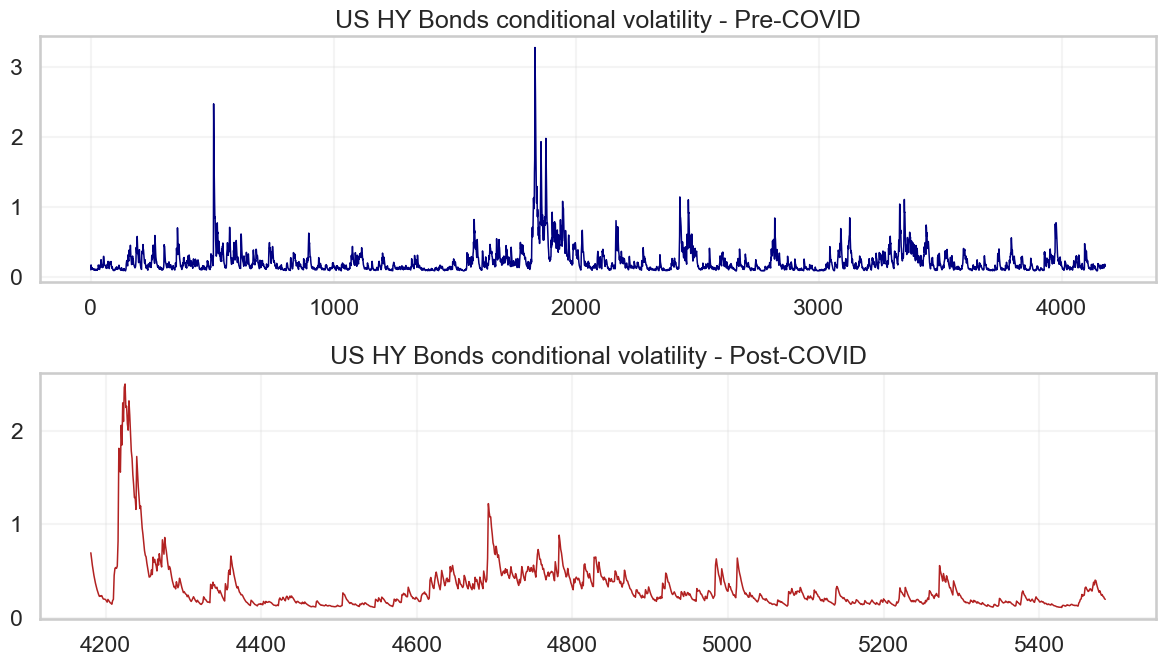

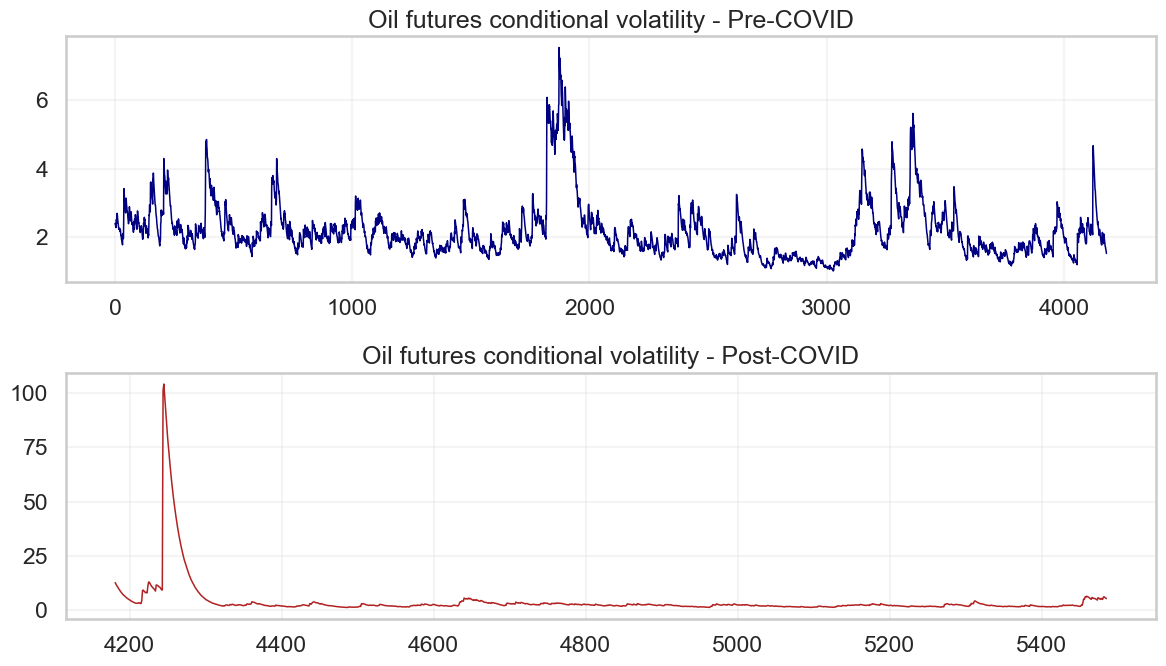

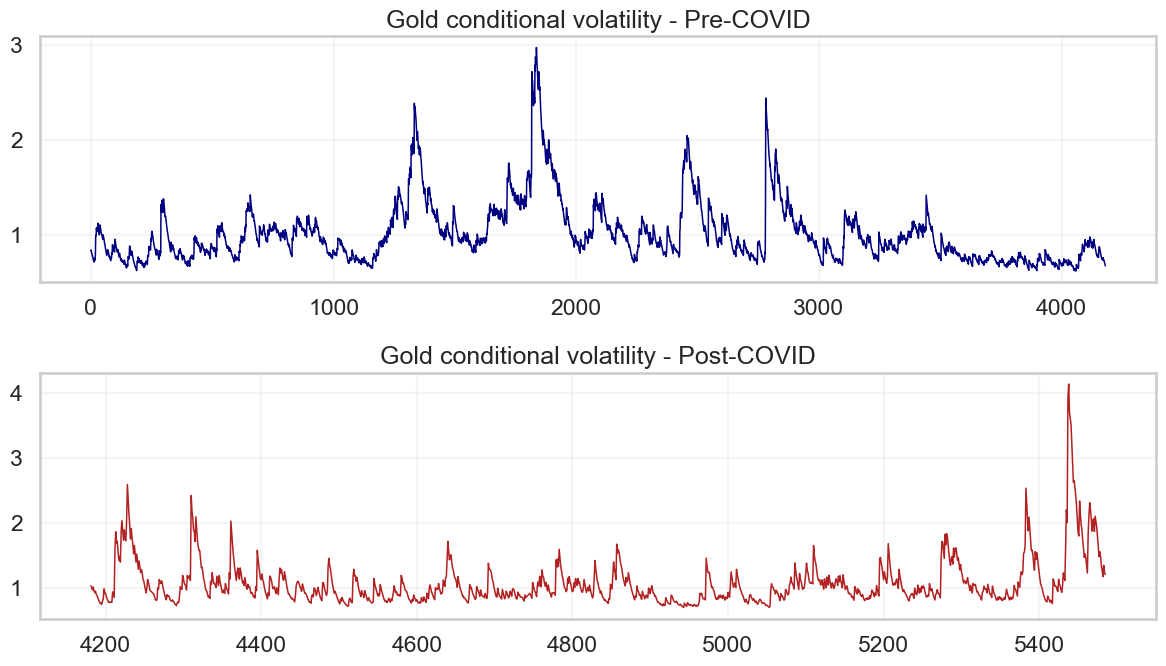

In [9]:
for asset_name in GARCH_ASSETS:
    volatility_figure = plot_conditional_volatility(
        pre_series=pre_covid[asset_name],
        post_series=post_covid[asset_name],
        asset_name=asset_name,
    )
    save_figure(volatility_figure, f"02_conditional_volatility_{asset_name}.png")
    plt.show()

## 9. A simple ranking of post-COVID persistence

The most direct way to summarize this notebook is to rank post-COVID persistence across the four assets. Highly persistent post-COVID volatility suggests that shocks take longer to dissipate, which is one concrete way in which the structure of risk may have changed.

In [10]:
post_persistence_ranking = (
    comparison_table.loc[comparison_table["sample"] == "Post-COVID", ["asset_label", "model", "persistence"]]
    .sort_values(["model", "persistence"], ascending=[True, False])
)
post_persistence_ranking

,asset_label,model,persistence
18,Oil futures,"GARCH(1,1)",1.0000
15,US HY Bonds,"GARCH(1,1)",1.0000
12,S&P 500,"GARCH(1,1)",0.9638
21,Gold,"GARCH(1,1)",0.9313
17,US HY Bonds,GARCH-t,1.0000
14,S&P 500,GARCH-t,0.9766
23,Gold,GARCH-t,0.9417
20,Oil futures,GARCH-t,0.8968
19,Oil futures,GJR-GARCH,1.0000
16,US HY Bonds,GJR-GARCH,1.0000


## 10. Main takeaways from notebook 02

This notebook tells us whether volatility persistence, leverage effects and heavy tails became more pronounced after COVID-19. These are core ingredients of the broader structure of risk. The next notebook will move from univariate volatility to cross-asset dependence through rolling correlations and DCC-GARCH.